In [80]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform
import pandas as pd

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [41]:
# df 객체를 파일로 저장
df.to_csv('data/kobis.csv', encoding='utf-8', index=False)

In [42]:
#월별 박스오피스 순위
df['날짜'] = pd.to_datetime(df['날짜'])

df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day
df['요일'] = df['날짜'].dt.weekday
df

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,년,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,2
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,2
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,2
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,2
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-31,6,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,2025-12-24,18979,327390,154747310,2025,12,31,2
3646,2025-12-31,7,화양연화 특별판,2025-12-31,9292,11279,80027452,2025,12,31,2
3647,2025-12-31,8,뽀로로 극장판 스위트캐슬 대모험,2025-12-11,4807,216003,41105520,2025,12,31,2
3648,2025-12-31,9,누벨바그,2025-12-31,4051,4597,24782960,2025,12,31,2


In [104]:
# 요일을 매핑하는 딕셔너리 객체 생성
week_dict = {
    0: '월',
    1: '화',
    2: '수',
    3: '목',
    4: '금',
    5: '토',
    6: '일'
}
df['요일'] = df['날짜'].dt.weekday.map(week_dict)
df['요일'].value_counts()

df['일일관객수'] = df['일일관객수'].astype(int)
df['일일매출액'] = df['일일매출액'].astype(int)
df

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,년,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,수
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,수
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,수
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,수
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,수
...,...,...,...,...,...,...,...,...,...,...,...
3645,2025-12-31,6,극장판 짱구는 못말려: 초화려! 작열하는 떡잎마을 댄서즈,2025-12-24,18979,327390,154747310,2025,12,31,수
3646,2025-12-31,7,화양연화 특별판,2025-12-31,9292,11279,80027452,2025,12,31,수
3647,2025-12-31,8,뽀로로 극장판 스위트캐슬 대모험,2025-12-11,4807,216003,41105520,2025,12,31,수
3648,2025-12-31,9,누벨바그,2025-12-31,4051,4597,24782960,2025,12,31,수


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[ns]
 1   순위      3650 non-null   object        
 2   영화명     3650 non-null   object        
 3   개봉일     3650 non-null   object        
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   object        
 6   일일매출액   3650 non-null   int64         
 7   년       3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   object        
dtypes: datetime64[ns](1), int32(3), int64(2), object(5)
memory usage: 271.0+ KB


In [106]:
df_rank1 = df[df['순위'] == '1']
df_rank1['일일관객수'].astype('int')

# 2025년 기준 Top Of Top 10
df_top10 = df_rank1.groupby('영화명')['일일관객수'].sum().sort_values(ascending=False).head(10)
df_top10

영화명
주토피아 2              5544162
좀비딸                 4699419
아바타: 불과 재           4568158
극장판 귀멸의 칼날: 무한성편    4406164
야당                  2859946
미키 17               2823360
미션 임파서블: 파이널 레코닝    2262437
히트맨2                1901945
승부                  1863085
보스                  1815197
Name: 일일관객수, dtype: int64

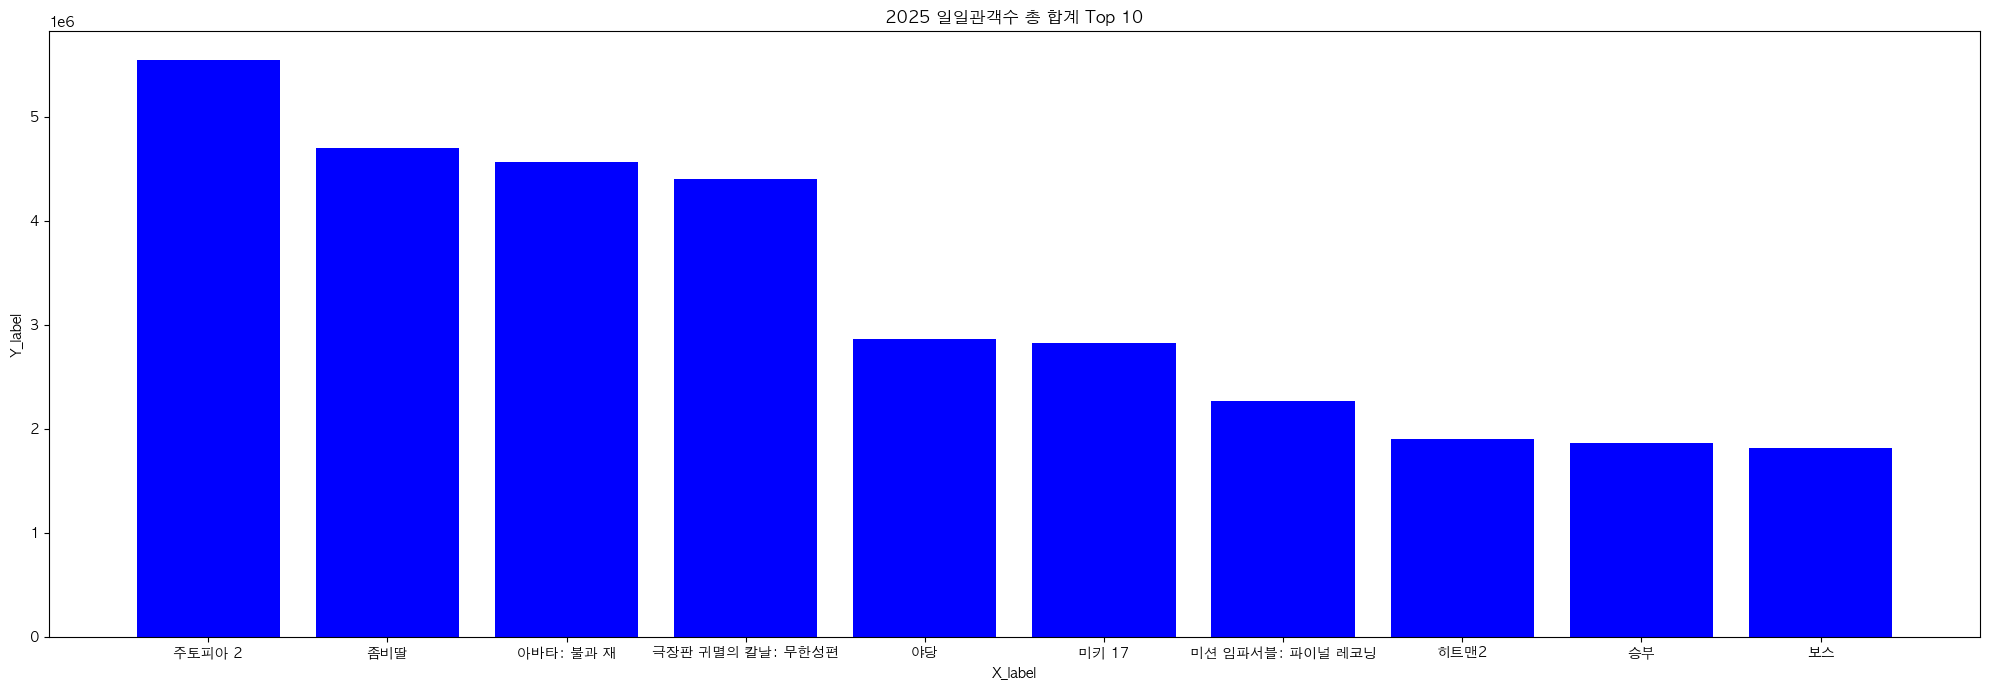

In [107]:
# 막대 그래프
plt.figure(figsize=(20, 7))
plt.bar(df_top10.index, df_top10.values, color='blue')
plt.title('2025 일일관객수 총 합계 Top 10')
plt.xlabel('X_label')
plt.ylabel('Y_label')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [119]:
# 월별 총 매출액 기준 Top 10
order = ['1월','2월','3월','4월','5월','6월','7월', '8월','9월','10월','11월','12월']
df_top10 = df.groupby('월')['일일매출액'].sum().sort_values(ascending=False).head(10)
df_total = df.groupby('월')['일일매출액'].sum()
df_top10
df_total

월
1      76426460660
2      47082683466
3      55772809470
4      46966204130
5      77570405180
6      69262625020
7     108647423776
8     126989955840
9      70064275110
10     89208664310
11     65397825630
12    134856286132
Name: 일일매출액, dtype: int64

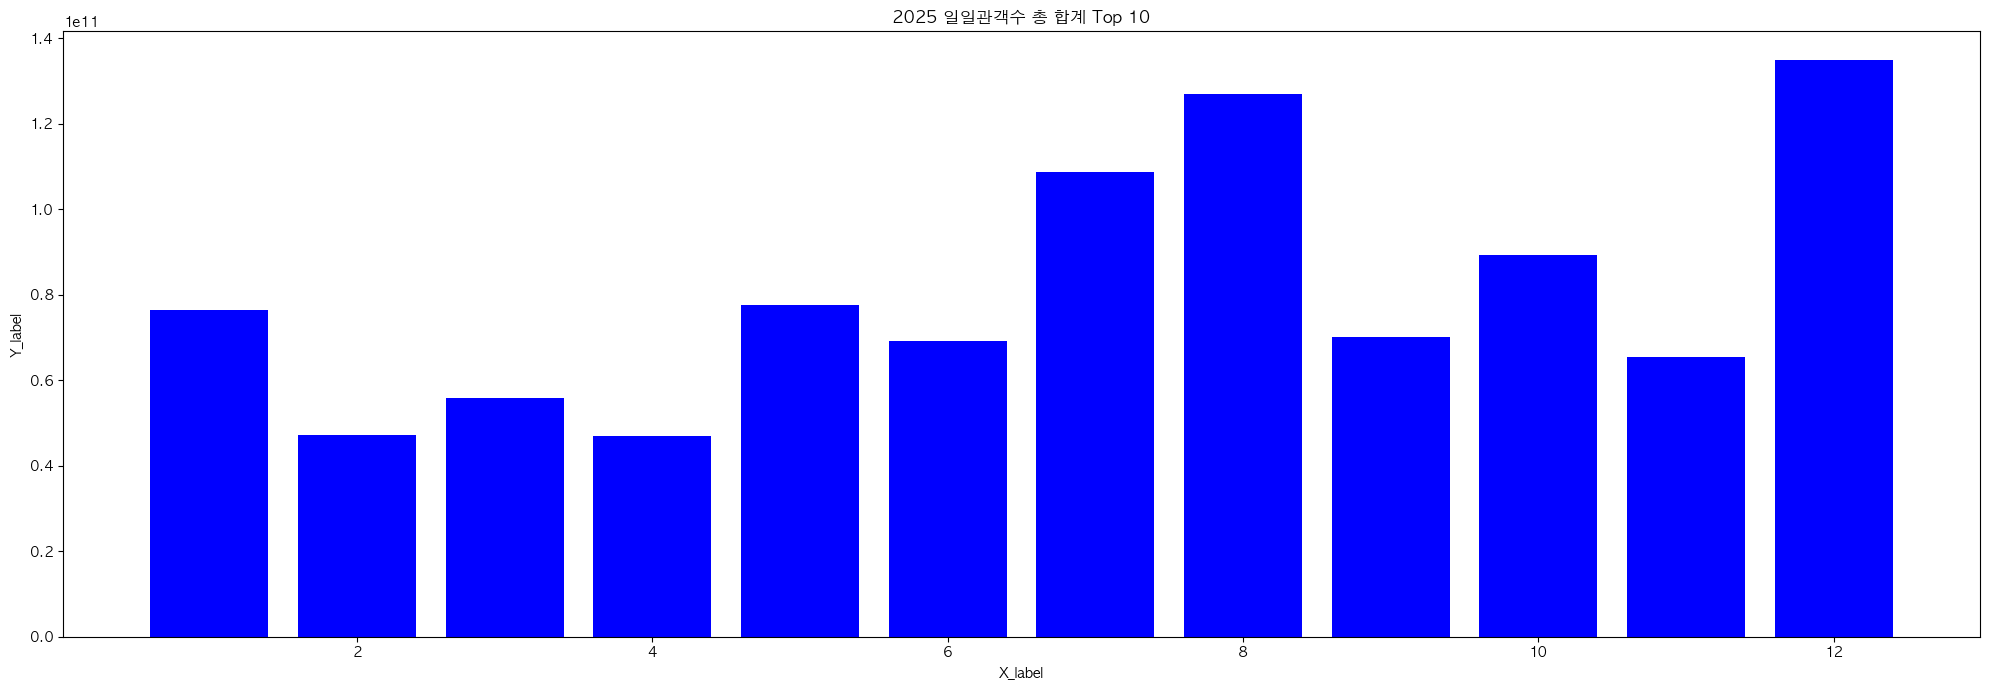

In [120]:
# 막대 그래프
plt.figure(figsize=(20, 7))
plt.bar(df_total.index, df_total.values, color='blue')
plt.title('2025 일일관객수 총 합계 Top 10')
plt.xlabel('X_labexl')
plt.ylabel('Y_label')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [128]:
df
# 요일별 관객수 추이
order = ['월','화','수','목','금','토','일']
df_week = df.groupby('요일')['일일관객수'].sum().reindex(order)

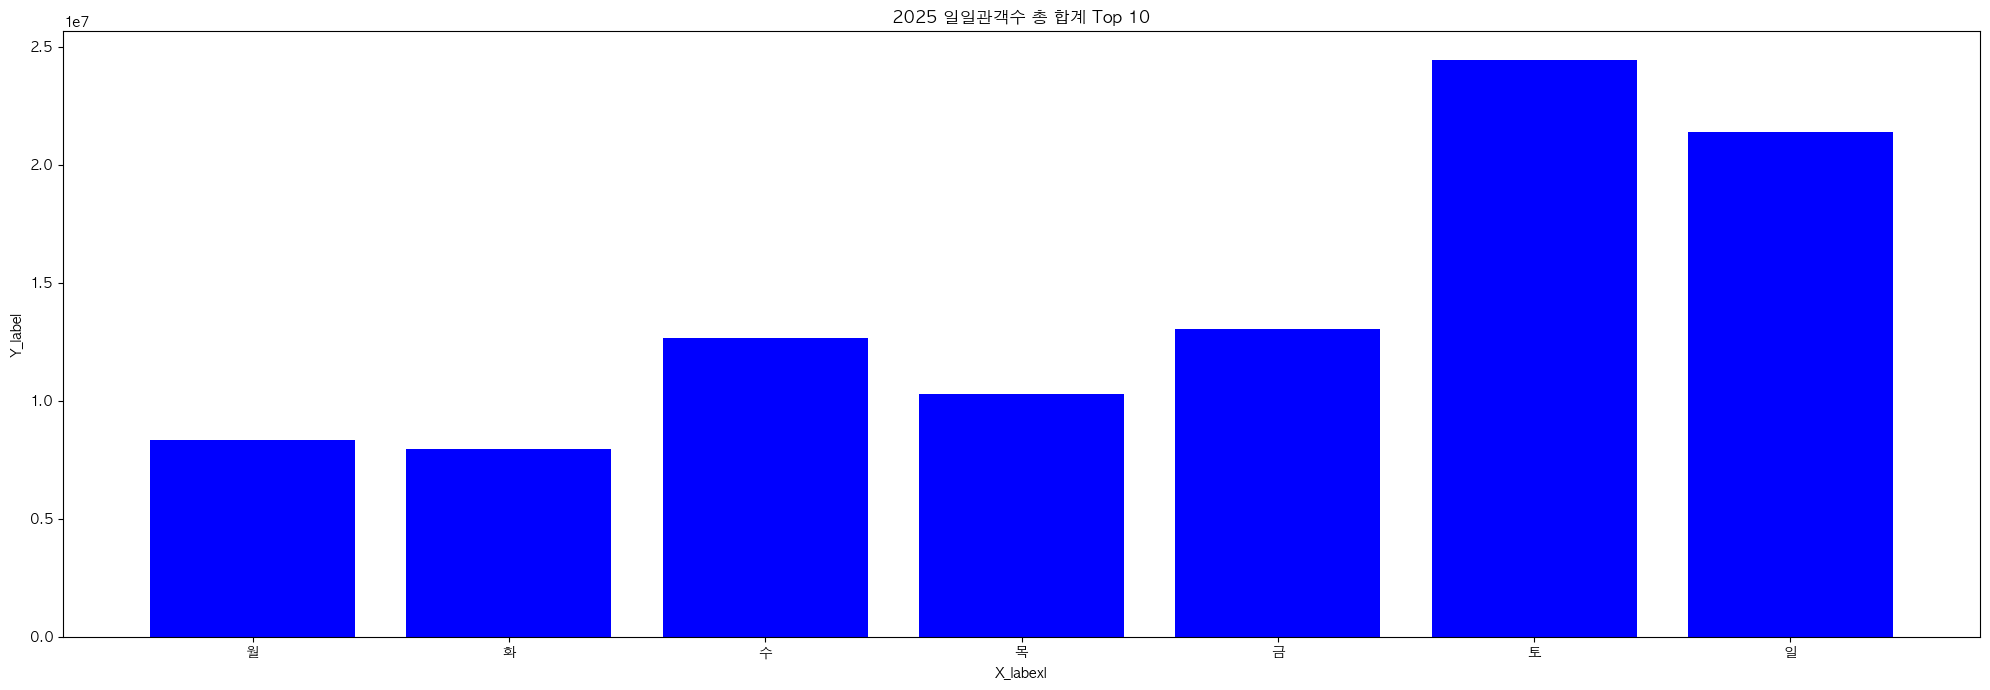

In [129]:
# 막대 그래프
plt.figure(figsize=(20, 7))
plt.bar(df_week.index, df_week.values, color='blue')
plt.title('2025 일일관객수 총 합계 Top 10')
plt.xlabel('X_labexl')
plt.ylabel('Y_label')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()